In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import glob

TOC:
- Overall Model Performance: Grouped Ba Chart, MAPE PErformance Comparison for 6 models
- Time Series Forecast Analysis: 6 individual line plots (Forecast vs. actual) = standardized on the same representative 7 day period (does this work with the output windows? I think no)
- Residual Error Analysis: Residual Distributions for each plot (LSTM vs TFT)
- VSN Feature Analysis: Encoder + Decoder Variable importance for TFT models (6)
- Cross-Horizon Importance analysis via Heatmap of encoder and decoder

# Results

In [3]:
final_results_data = {
    'Metric': ['MAE (MW)', 'RMSE (MW)', 'MAPE (%)'],
    'LSTM_Short':  [1638.22, 2395.48, 3.16],
    'TFT_Short':   [1492.99, 2377.45, 2.78],
    'LSTM_Medium': [2801.58, 4225.56, 5.50],
    'TFT_Medium':  [2140.66, 3247.54, 3.88],
    'LSTM_Long':   [3618.45, 5342.11, 7.26],
    'TFT_Long':    [1910.15, 2555.28, 3.49]
}

# --- 2. Create a Pandas DataFrame ---
# Pandas is the standard library for handling tabular data in Python.
df_results = pd.DataFrame(final_results_data)

# --- 3. Save the DataFrame to a CSV File ---
# Define the output directory and filename
output_dir = "outputs"
file_name = "final_model_performance_summary.csv"
save_path = os.path.join(output_dir, file_name)

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Save the data. index=False prevents pandas from writing the row numbers (0, 1, 2) as a column.
df_results.to_csv(save_path, index=False)

print("Results successfully saved to:")
print(save_path)

# --- Display the DataFrame to confirm it looks correct ---
print("\nPreview of the data:")
display(df_results)

Results successfully saved to:
outputs/final_model_performance_summary.csv

Preview of the data:


,Metric,LSTM_Short,TFT_Short,LSTM_Medium,TFT_Medium,LSTM_Long,TFT_Long
0,MAE (MW),1638.22,1492.99,2801.58,2140.66,3618.45,1910.15
1,RMSE (MW),2395.48,2377.45,4225.56,3247.54,5342.11,2555.28
2,MAPE (%),3.16,2.78,5.50,3.88,7.26,3.49


# Overall Performance Comparison Plot

In [5]:
plt.rcParams['font.family'] = ['sans-serif']

MODEL_COLORS = {
    'LSTM': '#587388',  # Slate Gray/Blue
    'TFT':  '#1D7874'   # Teal
}

In [6]:
results_data = {
    'Horizon': ['Short-Term (1-Day)', 'Short-Term (1-Day)', 
                'Medium-Term (7-Day)', 'Medium-Term (7-Day)', 
                'Long-Term (30-Day)', 'Long-Term (30-Day)'],
    'Model': ['LSTM', 'TFT', 'LSTM', 'TFT', 'LSTM', 'TFT'],
    'MAPE (%)': [3.16, 2.78, 5.50, 3.88, 7.26, 3.49] 
}
df_results = pd.DataFrame(results_data)

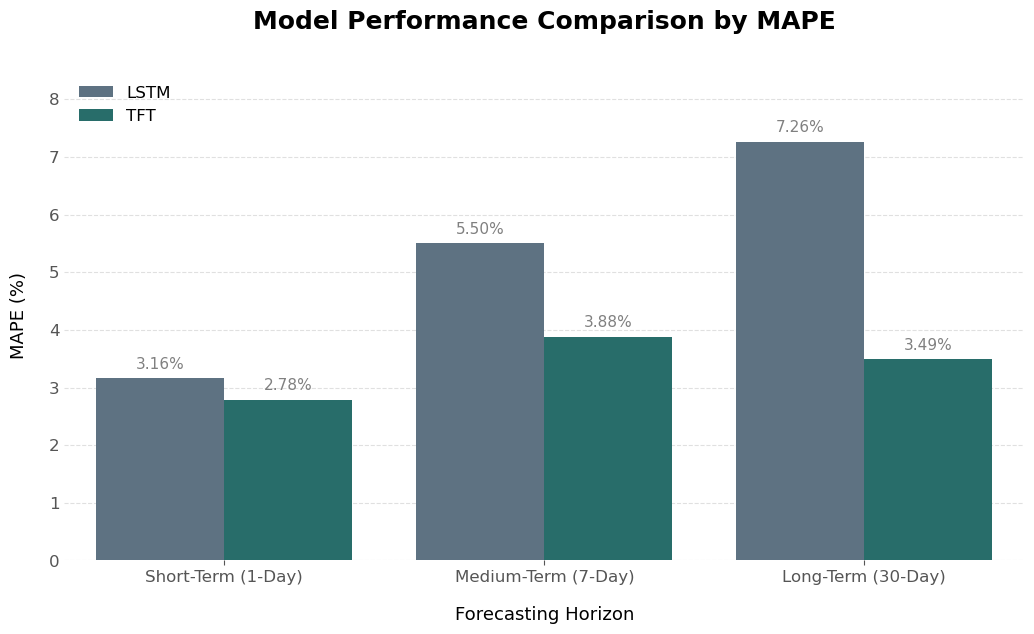

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_results, 
    x='Horizon', 
    y='MAPE (%)', 
    hue='Model',
    palette=MODEL_COLORS,
    ax=ax
)

ax.set_title('Model Performance Comparison by MAPE', pad=30, fontsize=18, weight='bold')

ax.grid(axis='y', linestyle='--', color='lightgray', alpha=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

ax.set_xlabel('Forecasting Horizon', fontsize=13, weight='light', labelpad=15)
ax.set_ylabel('MAPE (%)', fontsize=13, weight='light', labelpad=15)
ax.tick_params(axis='x', labelsize=12, colors='#555555')
ax.tick_params(axis='y', length=0, labelsize=12, colors='#555555')

ax.legend(title=None, frameon=False, loc='upper left', fontsize=12)

ax.set_ylim(0, 8.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=11, padding=5, color='gray')

plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.15)

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True) 
plt.savefig(os.path.join(output_dir, "mape_performance.png"), dpi=300)
plt.show()

# Time-Series Forecast Analysis
Not possible based on the way data was saved!

# Scatter Plot (Performance at Target Horizon)
Visual Representation of MAPE score, how well model's predictions for the final forecast step line up with the actual values.

In [ ]:
def plot_performance_scatter(prediction_file_path: str, model_name: str, horizon_name: str, horizon_step: int, output_dir: str = "outputs"):
    
    plt.rcParams['font.family'] = ['sans-serif']
    MODEL_COLORS = {'LSTM': '#587388', 'TFT': '#1D7874'}

    try:
        df = pd.read_csv(prediction_file_path)
    except FileNotFoundError:
        print(f"Error: File not found at {prediction_file_path}")
        return

    actual_col = f'actual_mw_step_{horizon_step}'
    predicted_col = f'predicted_mw_step_{horizon_step}'

    fig, ax = plt.subplots(figsize=(8, 8))
    
    sns.scatterplot(data=df, x=actual_col, y=predicted_col, color=MODEL_COLORS[model_name], alpha=0.5, s=40, ax=ax, edgecolor="none")
    
    perfect_line_range = [df[actual_col].min(), df[actual_col].max()]
    ax.plot(perfect_line_range, perfect_line_range, color='black', linestyle='--', label='Perfect Prediction')

    title_horizon_name = horizon_name.replace("_", " ").title()
    day_num = horizon_step // 96
    ax.set_title(f'{model_name} {title_horizon_name} Performance\n(Forecast at Day {day_num})', pad=20, fontsize=16, weight='bold')
    ax.set_xlabel(f'Actual Electricity Load (MW)', fontsize=12, labelpad=15)
    ax.set_ylabel(f'Predicted Electricity Load (MW)', fontsize=12, labelpad=15)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    
    os.makedirs(output_dir, exist_ok=True)
    file_name = f"{model_name}_{horizon_name}_scatter.png".lower().replace("-", "_")
    save_path = os.path.join(output_dir, file_name)
    
    plt.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.1)
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Plot saved to {save_path}\n")

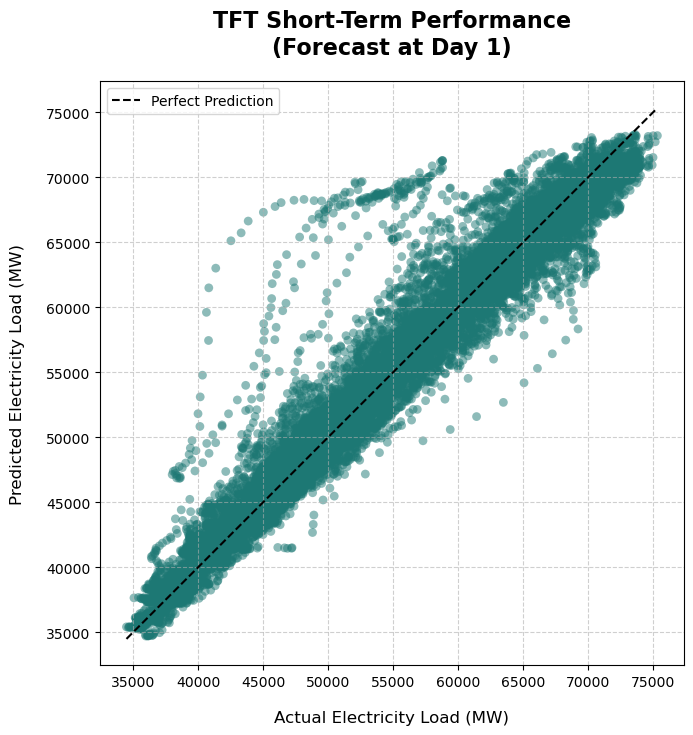

Plot saved to outputs/tft_short_term_scatter.png



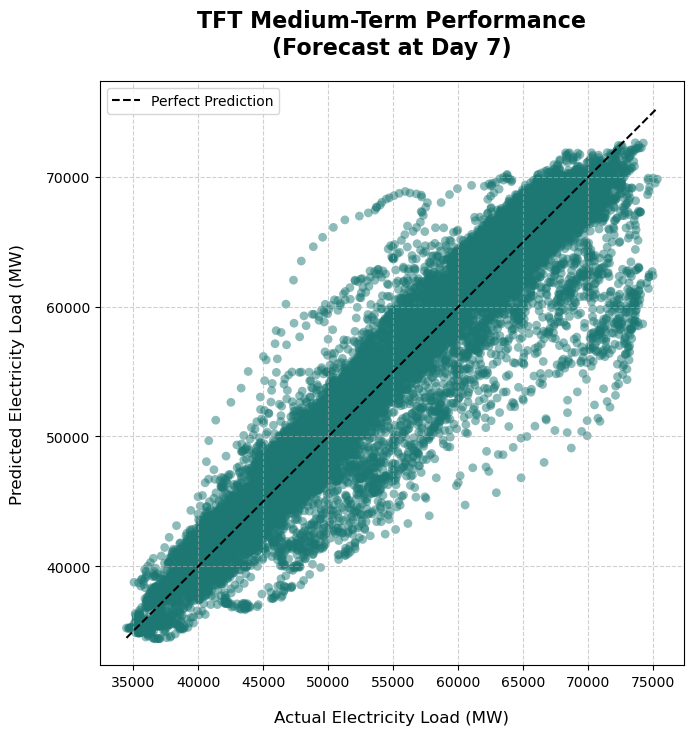

Plot saved to outputs/tft_medium_term_scatter.png



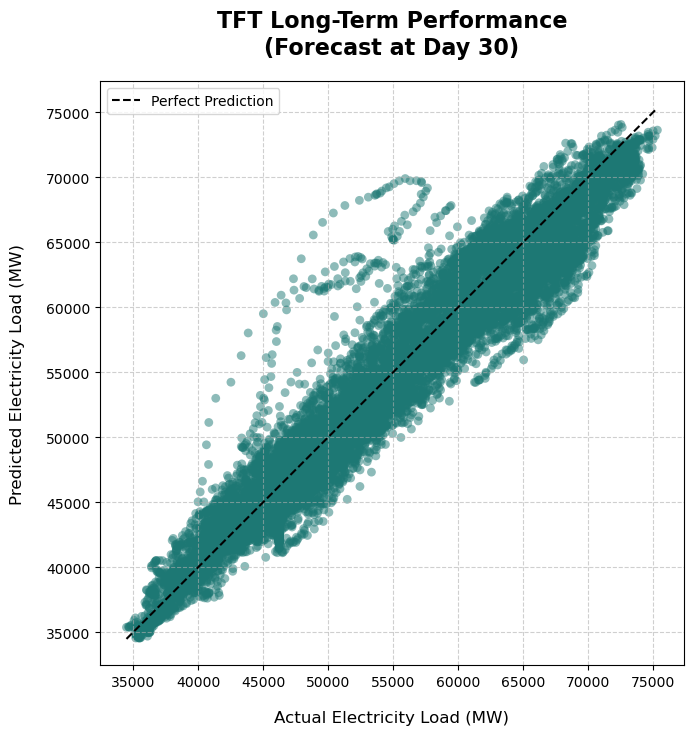

Plot saved to outputs/tft_long_term_scatter.png



In [31]:
plot_performance_scatter(
    prediction_file_path = "../outputs/tft_short_predictions_mw.csv",
    model_name = "TFT",
    horizon_name = "Short-Term",
    horizon_step = 96
)

plot_performance_scatter(
    prediction_file_path = "../outputs/tft_med_predictions_mw.csv",
    model_name = "TFT",
    horizon_name = "Medium-Term",
    horizon_step = 672
)

plot_performance_scatter(
    prediction_file_path = "../outputs/tft_long_predictions_mw.csv",
    model_name = "TFT",
    horizon_name = "Long-Term",
    horizon_step = 2880
)

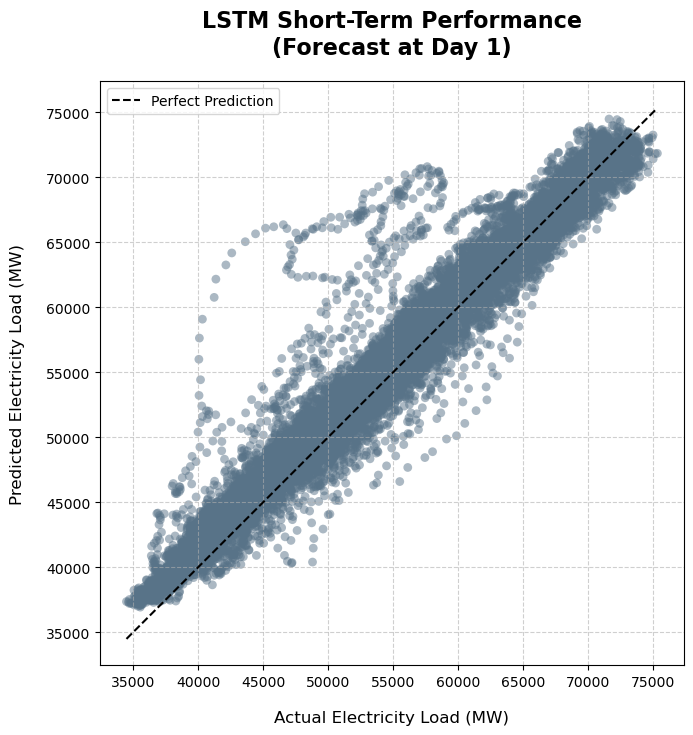

Plot saved to outputs/lstm_short_term_scatter.png



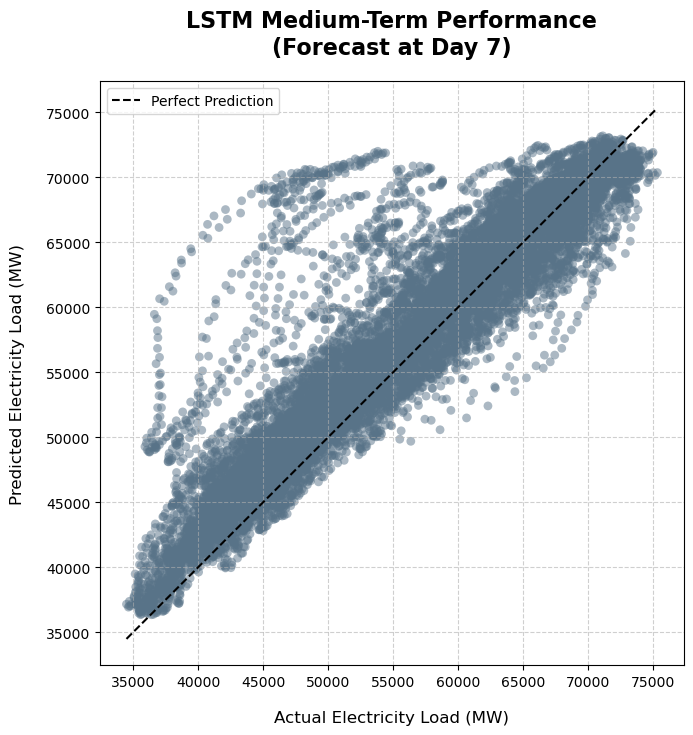

Plot saved to outputs/lstm_medium_term_scatter.png



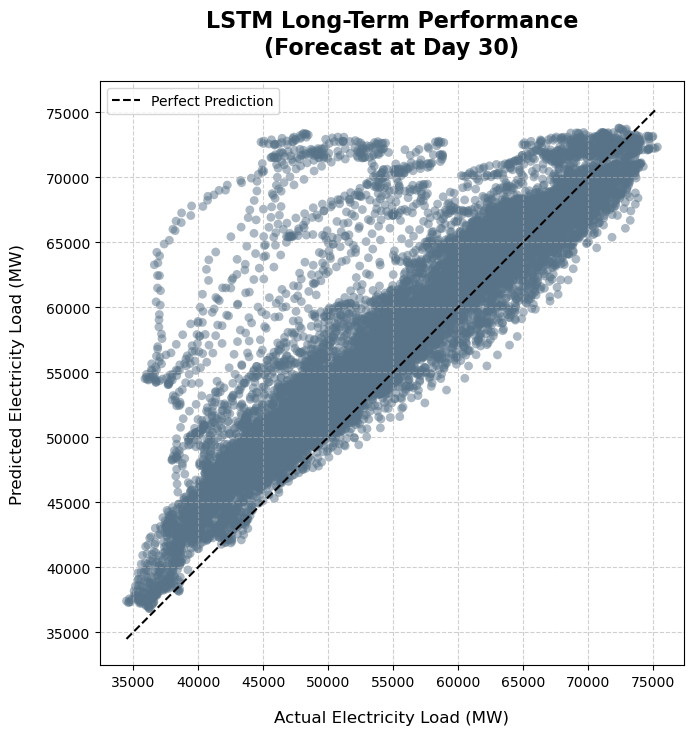

Plot saved to outputs/lstm_long_term_scatter.png



In [32]:
plot_performance_scatter(
    prediction_file_path = "../outputs/lstm_short_predictions_mw.csv",
    model_name = "LSTM",
    horizon_name = "Short-Term",
    horizon_step = 96
)

plot_performance_scatter(
    prediction_file_path = "../outputs/lstm_med_predictions_mw.csv",
    model_name = "LSTM",
    horizon_name = "Medium-Term",
    horizon_step = 672
)

plot_performance_scatter(
    prediction_file_path = "../outputs/lstm_long_predictions_mw.csv",
    model_name = "LSTM",
    horizon_name = "Long-Term",
    horizon_step = 2880
)

# Error Degradation Plot

In [43]:
def plot_error_degradation(prediction_file_path: str, model_name: str, horizon_name: str, horizon_step: int, output_dir: str = "outputs"):

    plt.rcParams['font.family'] = ['Helvetica', 'Arial', 'sans-serif']

    if model_name == 'LSTM':
        ERROR_COLORS = {'Near': '#9EADBA', 'Far': '#587388'}
    else:
        ERROR_COLORS = {'Near': '#64C5B3', 'Far': '#1D7874'}

    try:
        df = pd.read_csv(prediction_file_path)
    except FileNotFoundError:
        print(f"Error: File not found at {prediction_file_path}")
        return
        
    df['error_step_1'] = df['actual_mw_step_1'] - df['predicted_mw_step_1']
    df[f'error_step_{horizon_step}'] = df[f'actual_mw_step_{horizon_step}'] - df[f'predicted_mw_step_{horizon_step}']

    fig, ax = plt.subplots(figsize=(12, 7))

    sns.kdeplot(df['error_step_1'], ax=ax, label='Error at 15 Mins (Step 1)', color=ERROR_COLORS['Near'], fill=True, lw=2)
    sns.kdeplot(df[f'error_step_{horizon_step}'], ax=ax, label=f'Error at Day {horizon_step // 96}', color=ERROR_COLORS['Far'], fill=True, alpha=0.7, lw=2)
    
    ax.axvline(0, color='black', linestyle='--', alpha=0.6)
    title_horizon_name = horizon_name.replace("_", " ").title()
    ax.set_title(f'{model_name} {title_horizon_name}: Error Distribution vs. Forecast Distance', pad=20, fontsize=18, weight='bold')
    
    ax.set_xlabel('Prediction Error (MW)', fontsize=13, weight='light', labelpad=15)
    ax.set_ylabel('Density', fontsize=13, weight='light', labelpad=15)
    
    ax.grid(axis='y', linestyle='--', color='lightgray', alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    
    ax.legend(frameon=False, fontsize=12)
    
    os.makedirs(output_dir, exist_ok=True)
    file_name = f"{model_name}_{horizon_name}_error_degradation.png".lower().replace("-", "_")
    save_path = os.path.join(output_dir, file_name)
    
    plt.subplots_adjust(left=0.1, right=0.9, top=0.88, bottom=0.15)
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Plot saved to {save_path}\n")

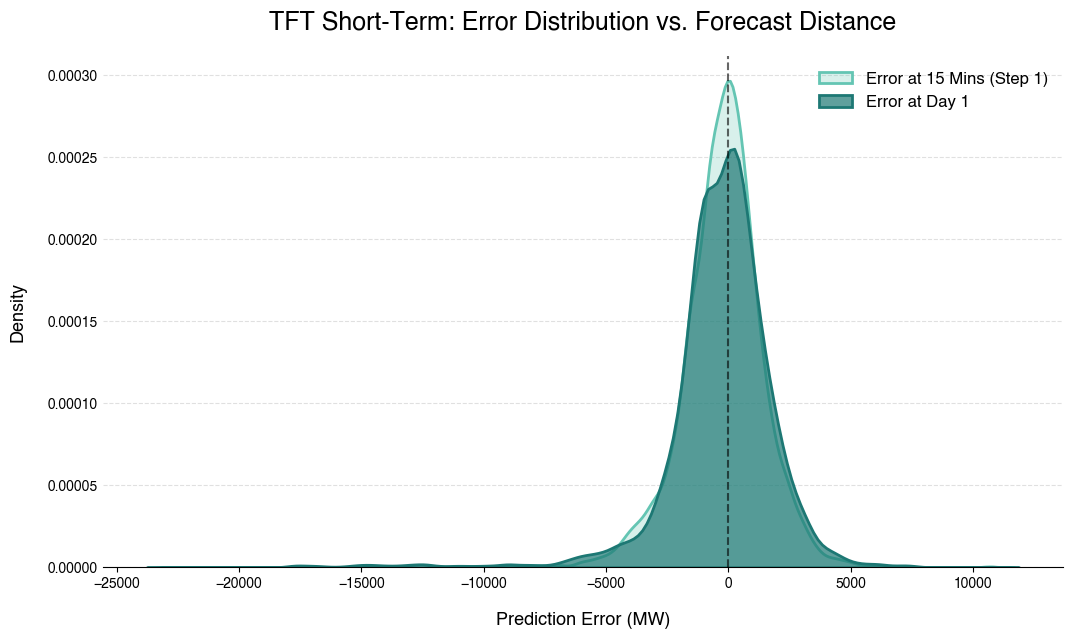

Plot saved to outputs/tft_short_term_error_degradation.png



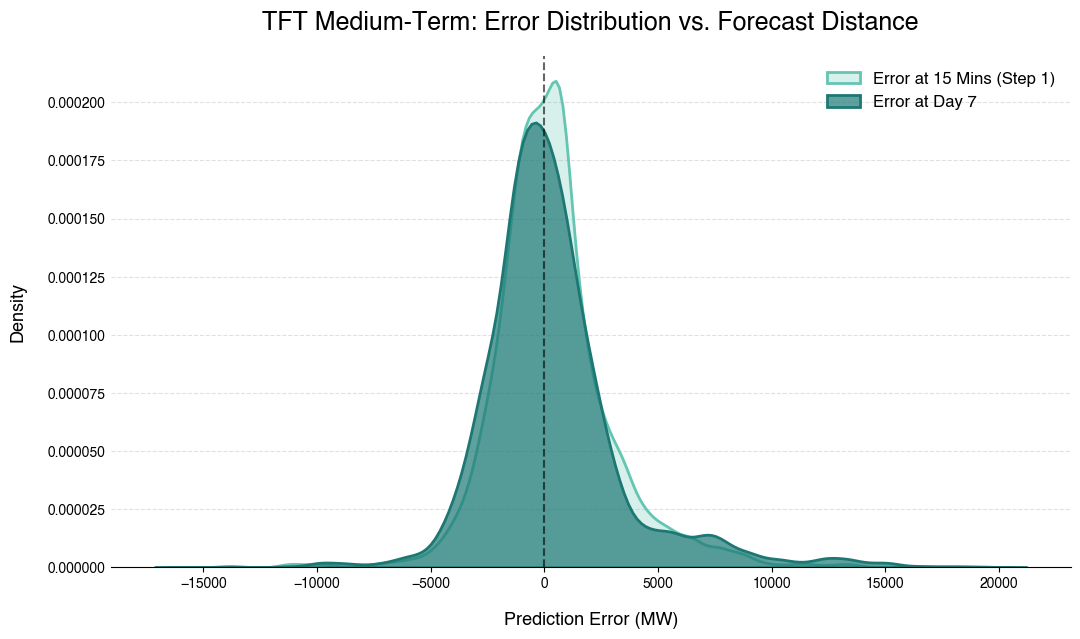

Plot saved to outputs/tft_medium_term_error_degradation.png



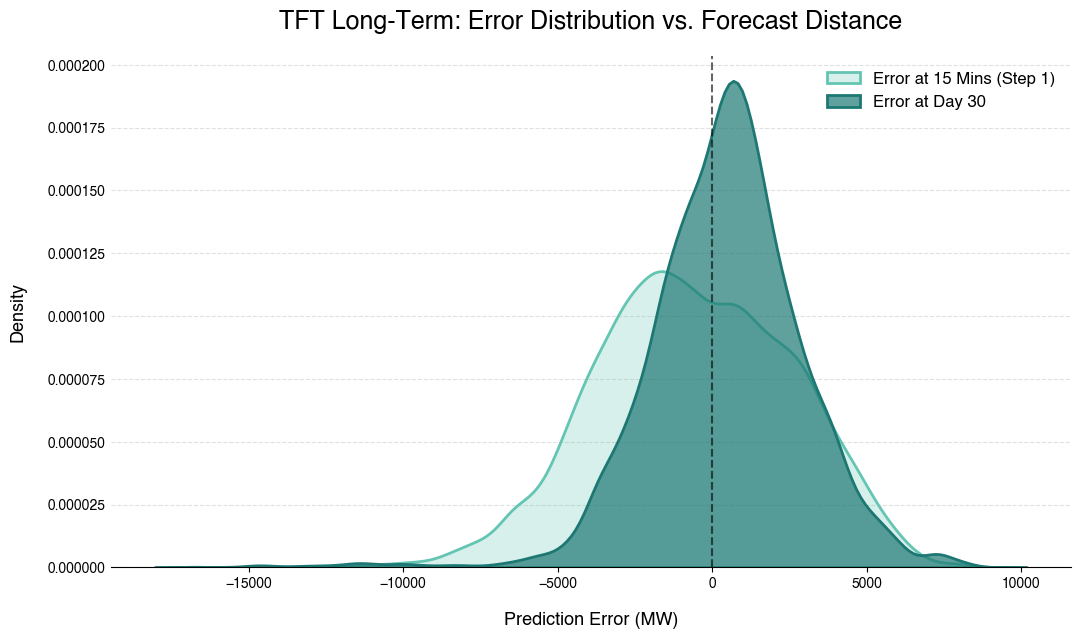

Plot saved to outputs/tft_long_term_error_degradation.png



In [44]:
plot_error_degradation(
    prediction_file_path = "../outputs/tft_short_predictions_mw.csv",
    model_name = "TFT",
    horizon_name = "Short-Term",
    horizon_step = 96
)

plot_error_degradation(
    prediction_file_path = "../outputs/tft_med_predictions_mw.csv",
    model_name = "TFT",
    horizon_name = "Medium-Term",
    horizon_step = 672
)

plot_error_degradation(
    prediction_file_path = "../outputs/tft_long_predictions_mw.csv",
    model_name = "TFT",
    horizon_name = "Long-Term",
    horizon_step = 2880
)

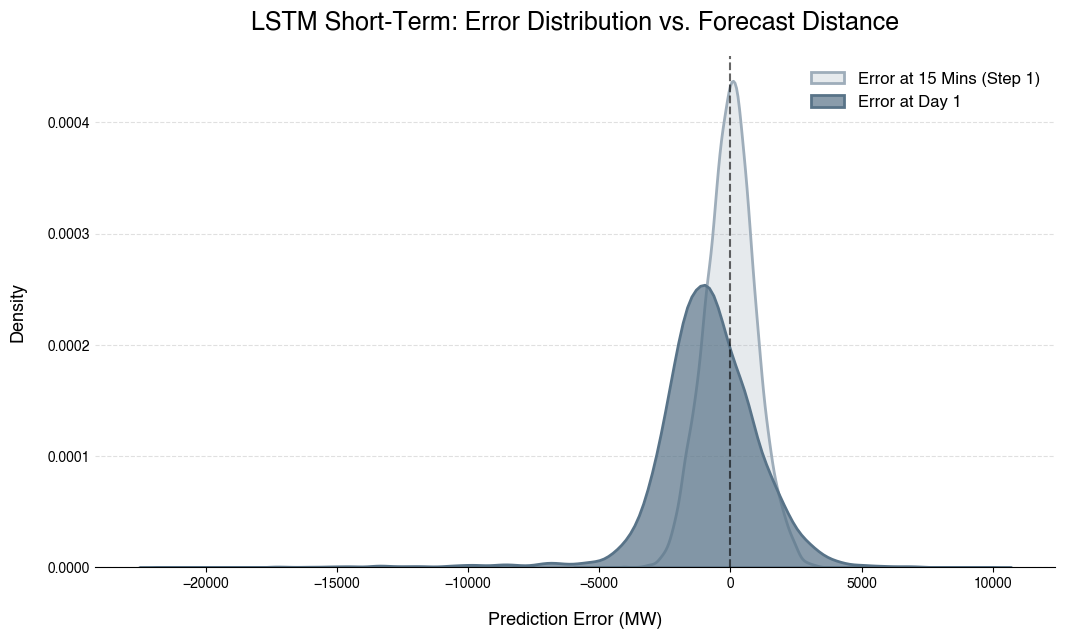

Plot saved to outputs/lstm_short_term_error_degradation.png



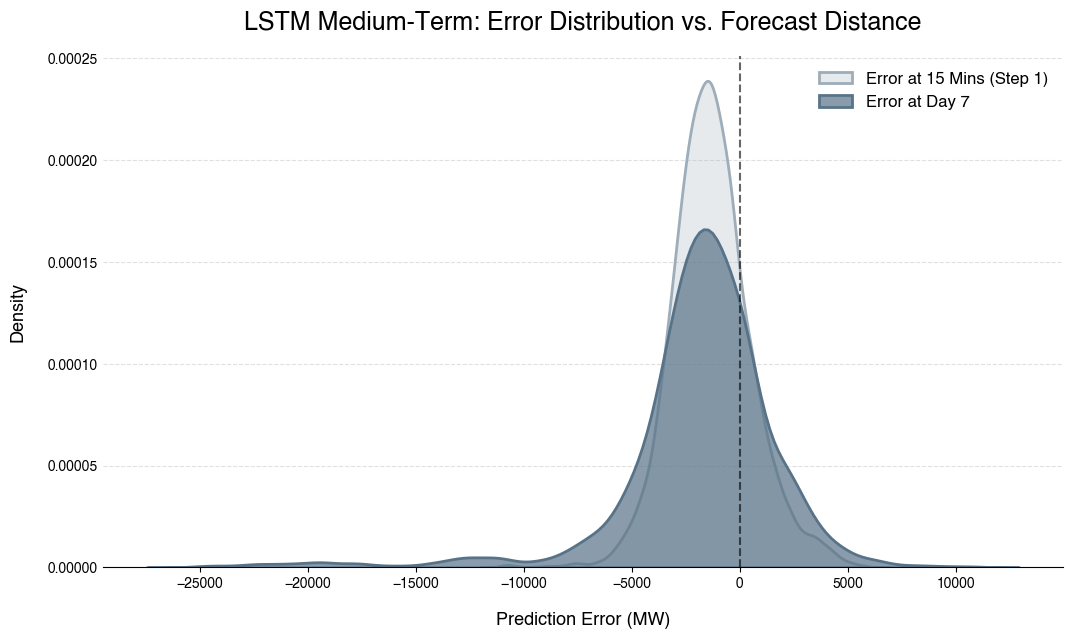

Plot saved to outputs/lstm_medium_term_error_degradation.png



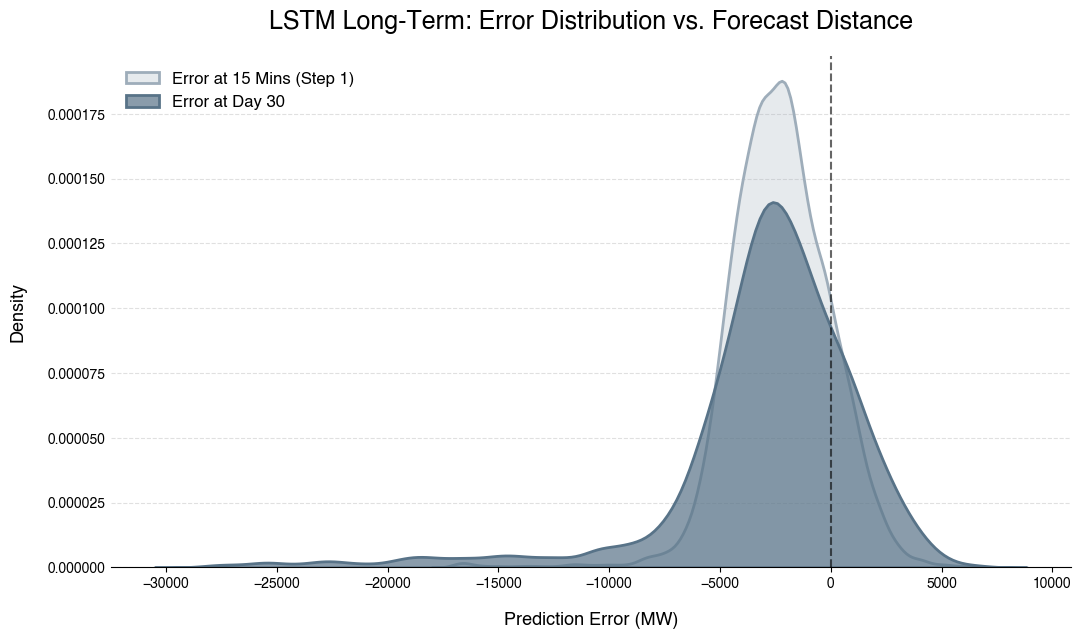

Plot saved to outputs/lstm_long_term_error_degradation.png



In [45]:
plot_error_degradation(
    prediction_file_path = "../outputs/lstm_short_predictions_mw.csv",
    model_name = "LSTM",
    horizon_name = "Short-Term",
    horizon_step = 96
)

plot_error_degradation(
    prediction_file_path = "../outputs/lstm_med_predictions_mw.csv",
    model_name = "LSTM",
    horizon_name = "Medium-Term",
    horizon_step = 672
)

plot_error_degradation(
    prediction_file_path = "../outputs/lstm_long_predictions_mw.csv",
    model_name = "LSTM",
    horizon_name = "Long-Term",
    horizon_step = 2880
)

# MAE vs RMSE Comparison

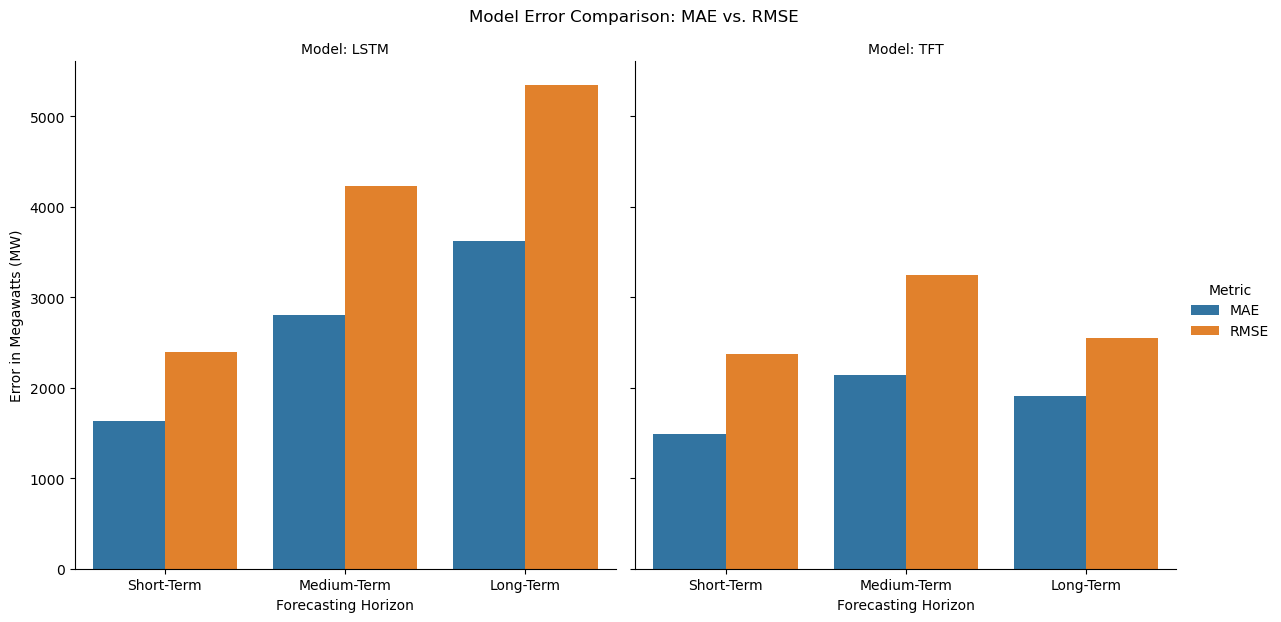

In [50]:

results_data = {
    'Horizon': ['Short-Term', 'Medium-Term', 'Long-Term'],
    'LSTM_MAE': [1638.22, 2801.58, 3618.45],
    'TFT_MAE': [1492.99, 2140.66, 1910.15],
    'LSTM_RMSE': [2395.48, 4225.56, 5342.11],
    'TFT_RMSE': [2377.45, 3247.54, 2555.28]
}
df_raw = pd.DataFrame(results_data)

df_melted = df_raw.melt(id_vars='Horizon', var_name='Metric_Type', value_name='Error (MW)')
df_melted[['Model', 'Metric']] = df_melted['Metric_Type'].str.split('_', expand=True)


g = sns.catplot(
    data=df_melted, 
    x='Horizon', 
    y='Error (MW)', 
    hue='Metric',      # The bars will be colored by MAE vs. RMSE
    col='Model',       # This creates the two separate plots for LSTM and TFT
    kind='bar',
    height=6, 
    aspect=1.0
)

g.fig.suptitle('Model Error Comparison: MAE vs. RMSE', y=1.03) # y > 1 adds space
g.set_titles("Model: {col_name}")
g.set_axis_labels("Forecasting Horizon", "Error in Megawatts (MW)")

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)
# The savefig command should be called on the figure object 'g'
g.savefig(os.path.join(output_dir, "mae_vs_rmse_comparison_simple.png"), dpi=300)

plt.show()

# fix formating later.

# Residual error analysis

In [52]:
def plot_residual_comparison(lstm_pred_file: str, tft_pred_file: str, horizon_name: str, horizon_step: int, output_dir: str = "outputs"):

    plt.rcParams['font.family'] = ['sans-serif']
    MODEL_COLORS = {'LSTM': '#587388', 'TFT': '#1D7874'}

    try:
        df_lstm = pd.read_csv(lstm_pred_file)
        df_tft = pd.read_csv(tft_pred_file)
    except FileNotFoundError as e:
        print(f"Error: Could not find a prediction file. {e}")
        return
        
    actual_col = f'actual_mw_step_{horizon_step}'
    predicted_col = f'predicted_mw_step_{horizon_step}'
    df_lstm['residuals'] = df_lstm[actual_col] - df_lstm[predicted_col]
    df_tft['residuals'] = df_tft[actual_col] - df_tft[predicted_col]

    fig, ax = plt.subplots(figsize=(12, 7))

    sns.kdeplot(df_tft['residuals'], ax=ax, color=MODEL_COLORS['TFT'], label='TFT Errors', fill=True, lw=2)
    sns.kdeplot(df_lstm['residuals'], ax=ax, color=MODEL_COLORS['LSTM'], label='LSTM Errors', fill=True, alpha=0.6, lw=2)
    
    ax.axvline(0, color='black', linestyle='--', alpha=0.6, label='Zero Error (Perfect Forecast)')
    title_horizon_name = horizon_name.replace("_", " ").title()
    ax.set_title(f'Comparison of Model Error Distributions\n({title_horizon_name} Horizon)', pad=20, fontsize=18, weight='bold')
    
    ax.set_xlabel('Prediction Error (MW)', fontsize=13, weight='light', labelpad=15)
    ax.set_ylabel('Density', fontsize=13, weight='light', labelpad=15)
    
    ax.grid(axis='y', linestyle='--', color='lightgray', alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    
    ax.legend(frameon=False, fontsize=12)
    
    os.makedirs(output_dir, exist_ok=True)
    file_name = f"residual_distribution_{horizon_name.lower()}.png"
    save_path = os.path.join(output_dir, file_name)
    
    plt.subplots_adjust(left=0.1, right=0.9, top=0.88, bottom=0.15)
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Plot saved to {save_path}\n")

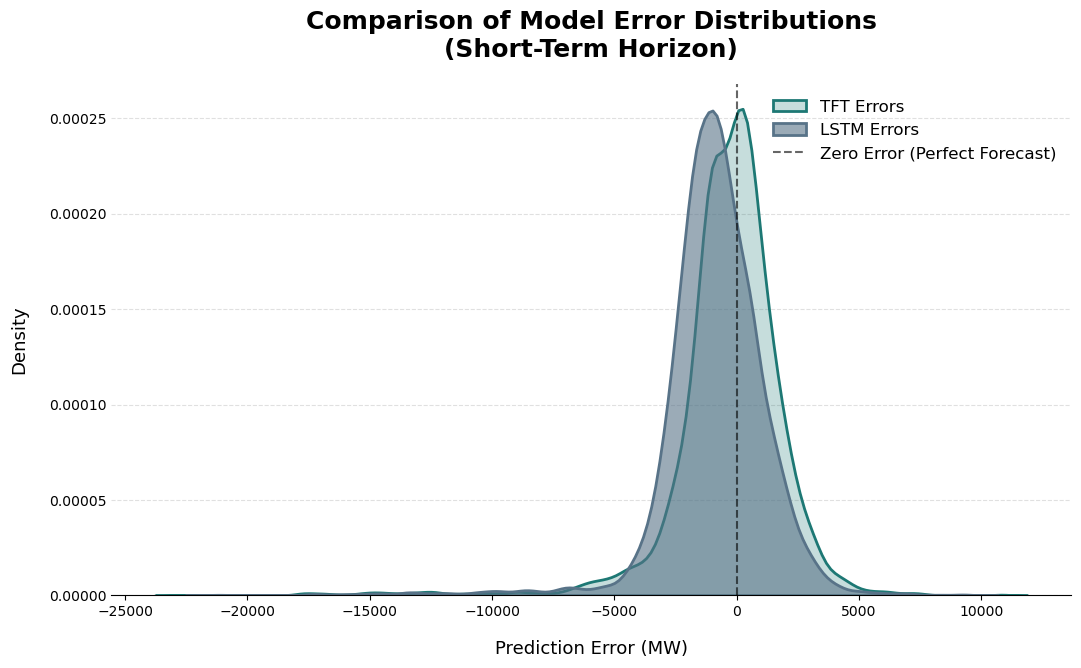

Plot saved to outputs/residual_distribution_short-term.png



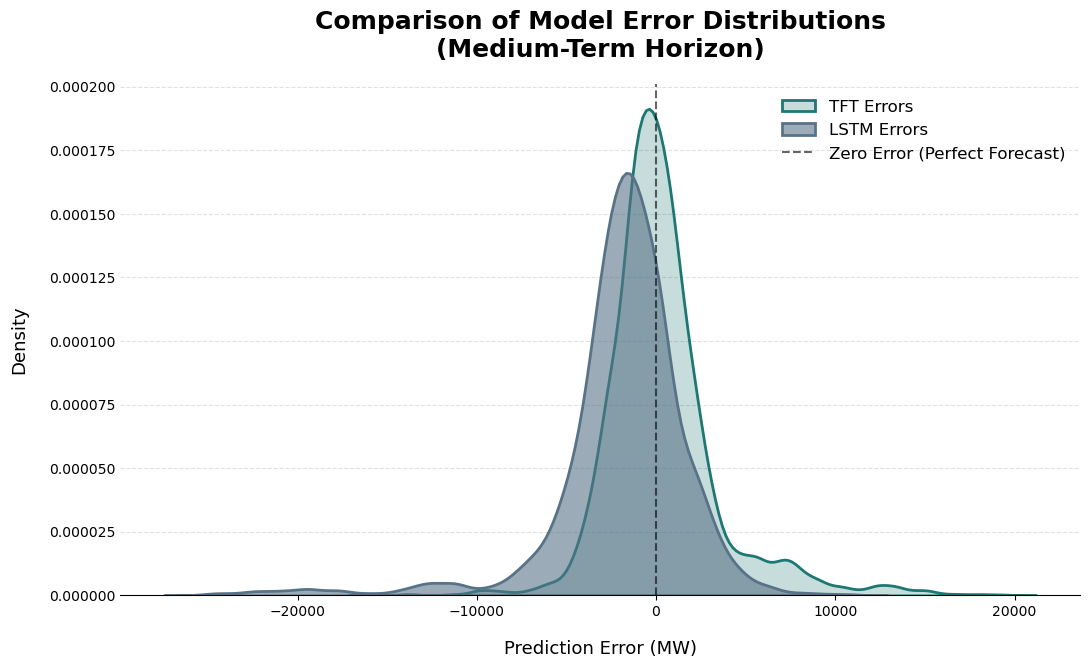

Plot saved to outputs/residual_distribution_medium-term.png



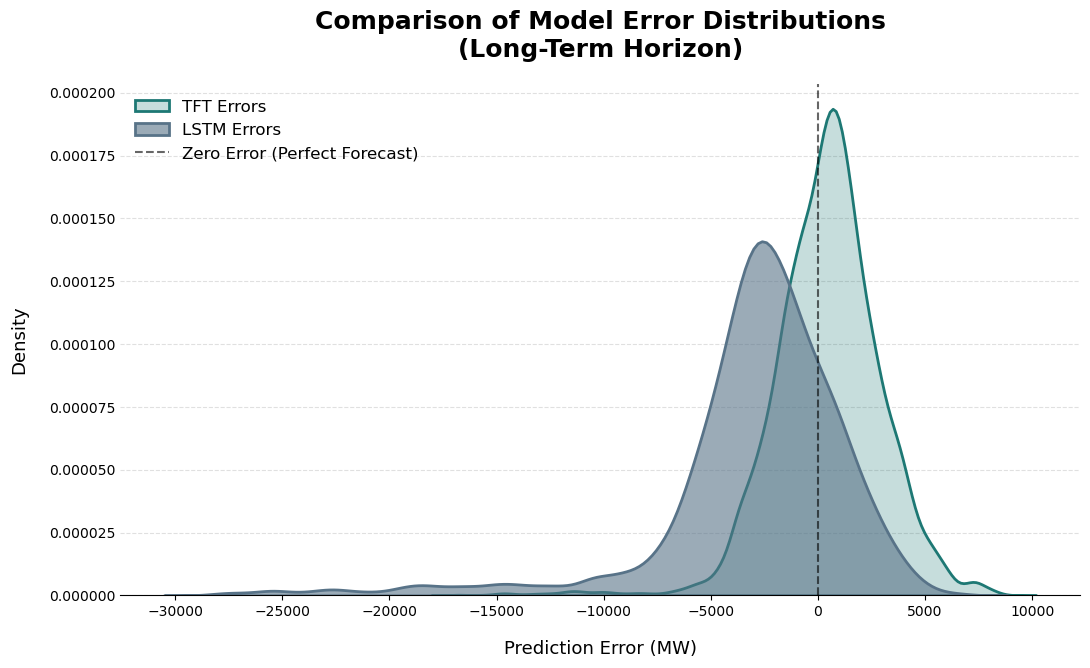

Plot saved to outputs/residual_distribution_long-term.png



In [53]:
plot_residual_comparison(
    lstm_pred_file="../outputs/lstm_short_predictions_mw.csv",
    tft_pred_file="../outputs/tft_short_predictions_mw.csv",
    horizon_name="Short-Term",
    horizon_step=96
)

plot_residual_comparison(
    lstm_pred_file="../outputs/lstm_med_predictions_mw.csv",
    tft_pred_file="../outputs/tft_med_predictions_mw.csv",
    horizon_name="Medium-Term",
    horizon_step=672
)

plot_residual_comparison(
    lstm_pred_file="../outputs/lstm_long_predictions_mw.csv",
    tft_pred_file="../outputs/tft_long_predictions_mw.csv",
    horizon_name="Long-Term",
    horizon_step=2880
)

# VSN Feature Importance Analysis

In [56]:
def plot_vsn_importance(vsn_scores_file: str, plot_title: str, color: str, top_n: int = 15, output_dir: str = "outputs"):

    plt.rcParams['font.family'] = ['sans-serif']

    try:
        df = pd.read_csv(vsn_scores_file)
    except FileNotFoundError:
        print(f"Error: VSN scores file not found at {vsn_scores_file}")
        return

    df_top = df.head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.barplot(data=df_top, y='feature', x='importance', color=color, ax=ax)
    
    ax.set_title(plot_title, pad=20, fontsize=18, weight='bold')
    ax.set_xlabel('VSN Importance Score', fontsize=13, weight='light', labelpad=15)
    ax.set_ylabel('Feature', fontsize=13, weight='light', labelpad=15)
    
    ax.grid(axis='x', linestyle='--', color='lightgray', alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.tick_params(axis='x', colors='gray')
    
    os.makedirs(output_dir, exist_ok=True)
    file_name = f"{plot_title.replace(' ', '_').replace(':', '')}.png".lower()
    save_path = os.path.join(output_dir, file_name)
    
    plt.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.1)
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Plot saved to {save_path}\n")

# consider putting most important @ the top!

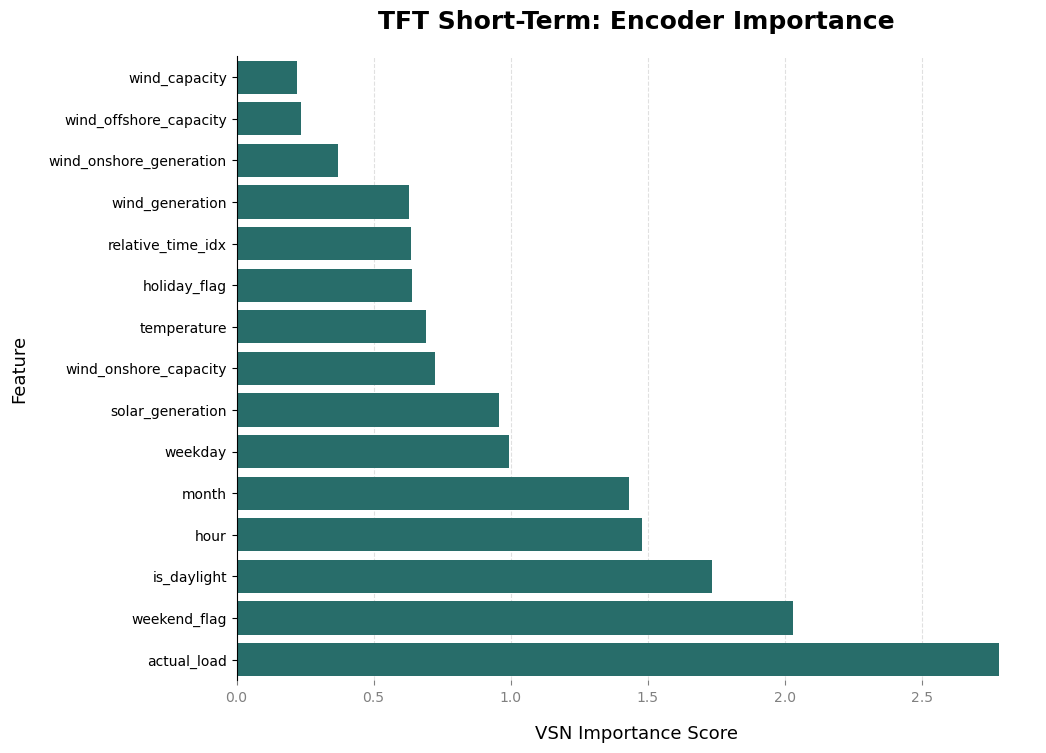

Plot saved to outputs/tft_short-term_encoder_importance.png



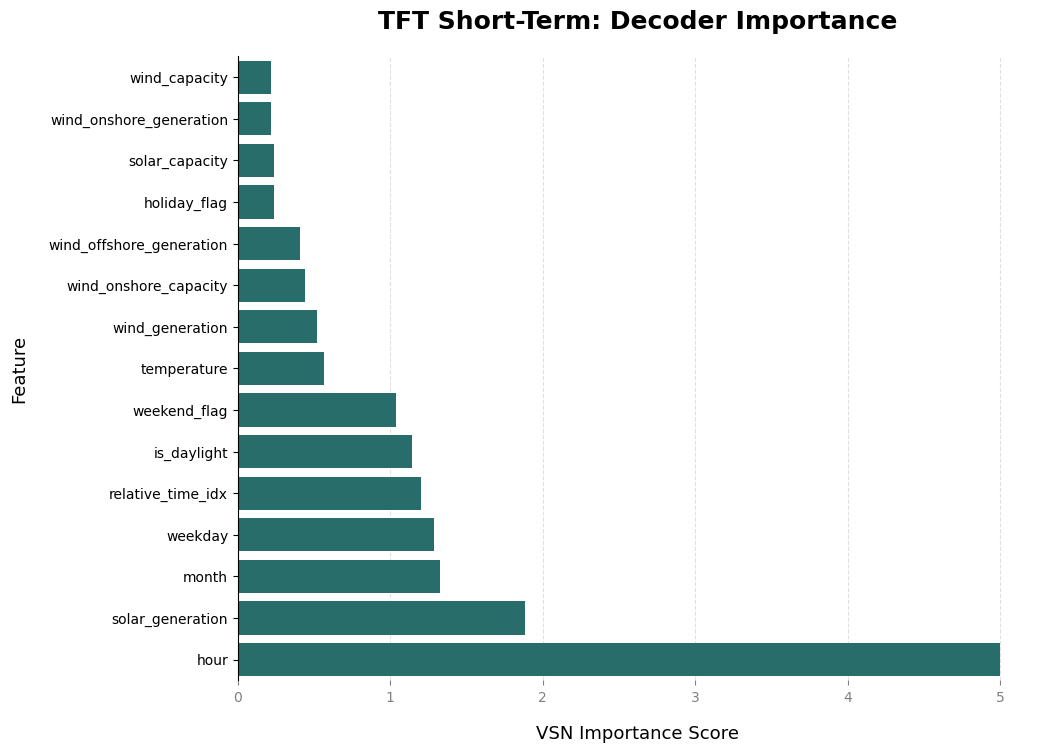

Plot saved to outputs/tft_short-term_decoder_importance.png



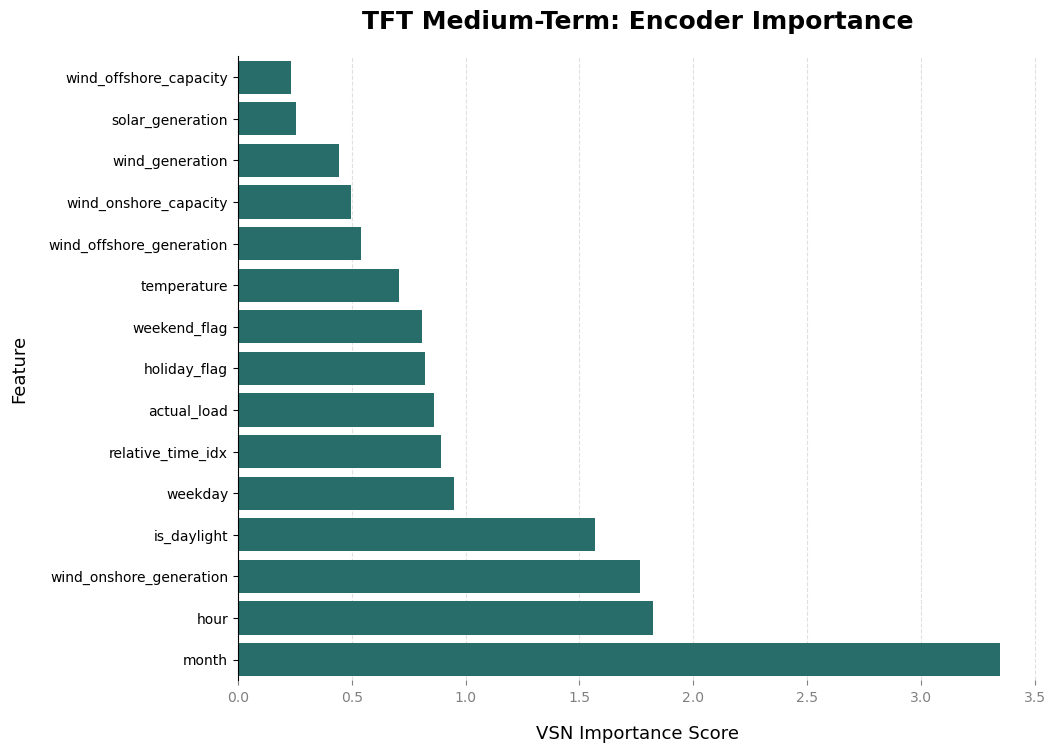

Plot saved to outputs/tft_medium-term_encoder_importance.png



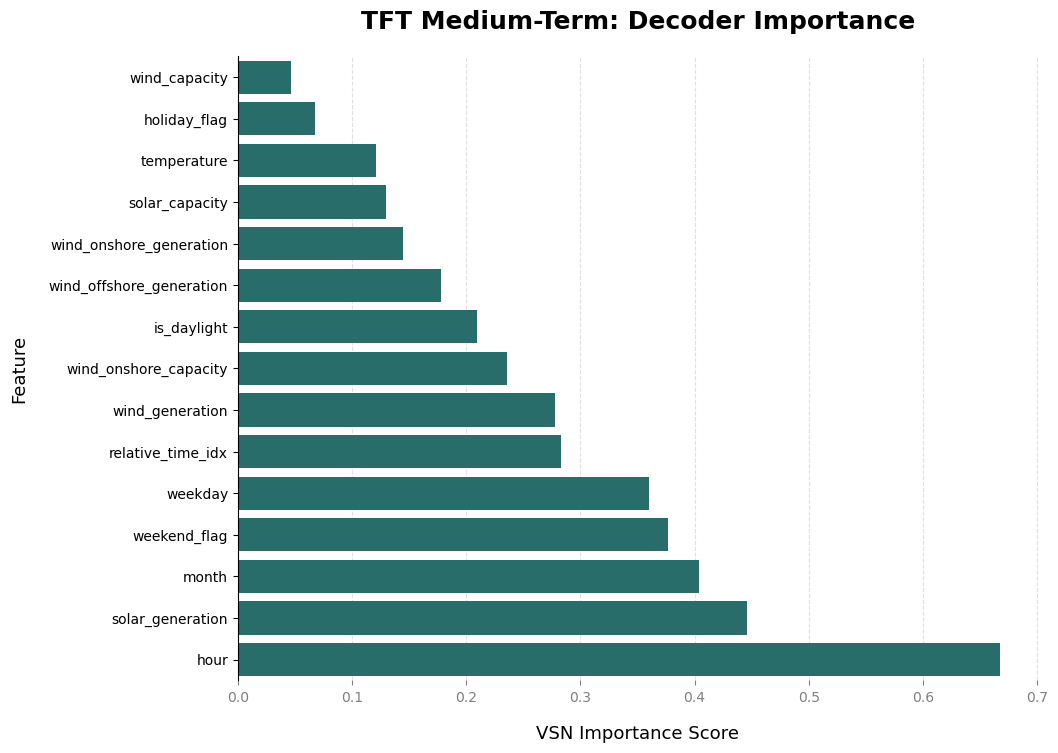

Plot saved to outputs/tft_medium-term_decoder_importance.png



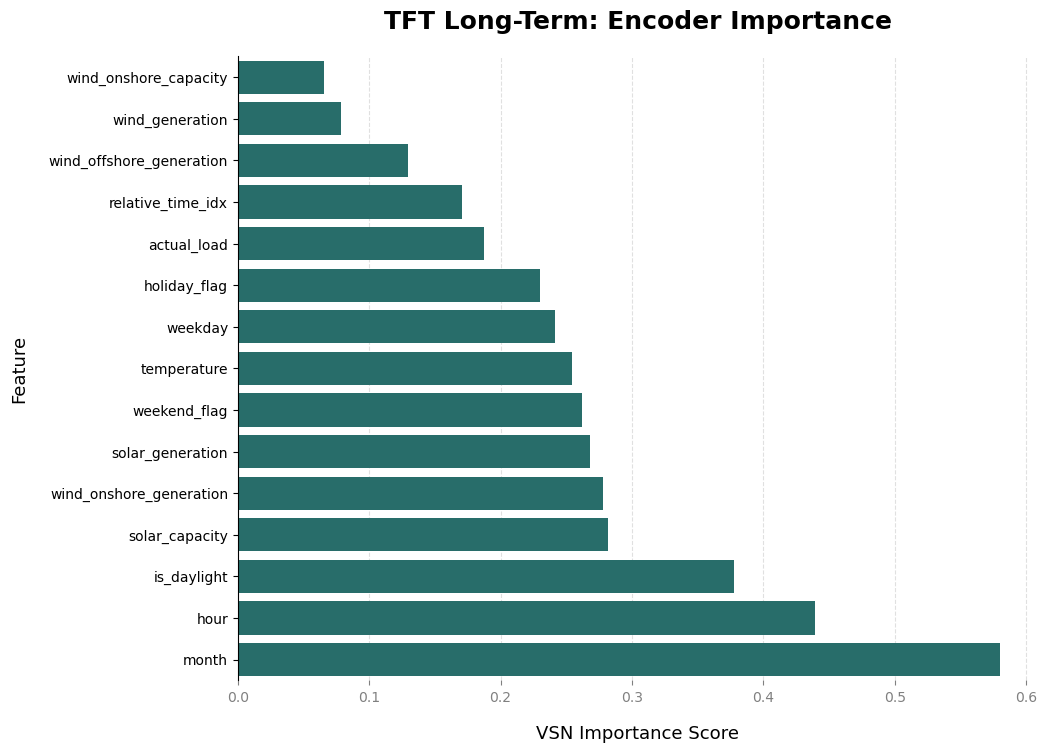

Plot saved to outputs/tft_long-term_encoder_importance.png



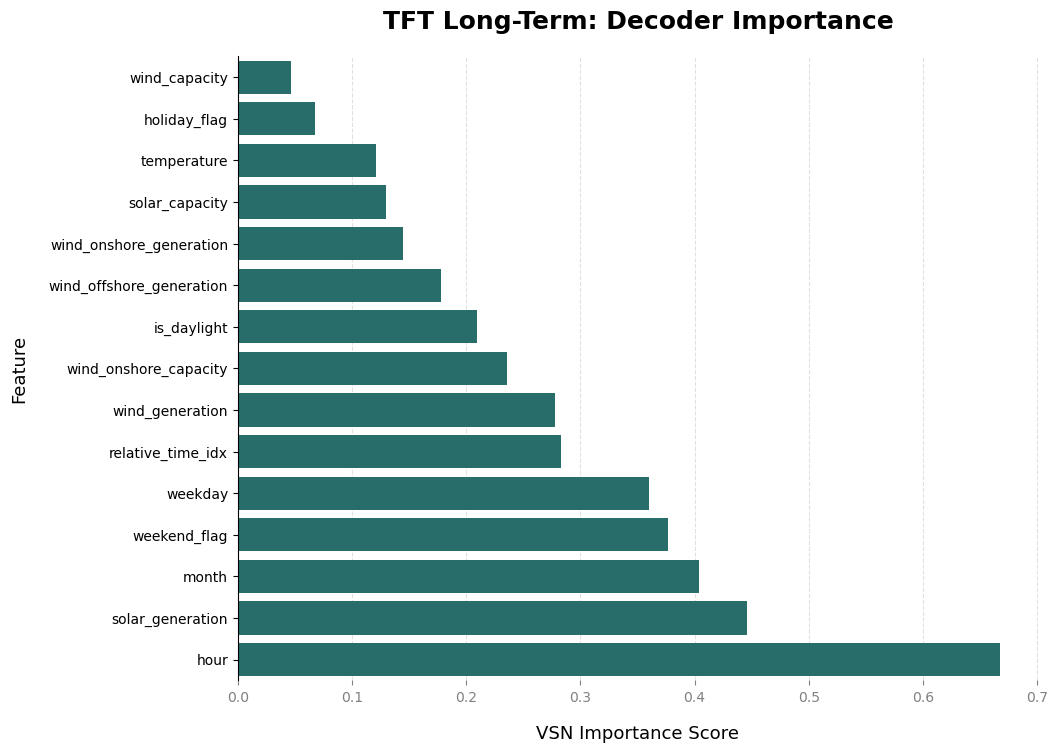

Plot saved to outputs/tft_long-term_decoder_importance.png



In [57]:
TFT_COLOR = '#1D7874' 

plot_vsn_importance(
    vsn_scores_file="../outputs/vsn_scores_encoder_variables_short.csv",
    plot_title="TFT Short-Term: Encoder Importance",
    color=TFT_COLOR
)
plot_vsn_importance(
    vsn_scores_file="../outputs/vsn_scores_decoder_variables_short.csv",
    plot_title="TFT Short-Term: Decoder Importance",
    color=TFT_COLOR
)
plot_vsn_importance(
    vsn_scores_file="../outputs/vsn_scores_encoder_variables_medium.csv",
    plot_title="TFT Medium-Term: Encoder Importance",
    color=TFT_COLOR
)
plot_vsn_importance(
    vsn_scores_file="../outputs/vsn_scores_decoder_variables_long.csv",
    plot_title="TFT Medium-Term: Decoder Importance",
    color=TFT_COLOR
)

plot_vsn_importance(
    vsn_scores_file="../outputs/vsn_scores_encoder_variables_long.csv",
    plot_title="TFT Long-Term: Encoder Importance",
    color=TFT_COLOR
)
plot_vsn_importance(
    vsn_scores_file="../outputs/vsn_scores_decoder_variables_long.csv",
    plot_title="TFT Long-Term: Decoder Importance",
    color=TFT_COLOR
)

# Cross Horizon Heatmaps

In [62]:
def plot_vsn_heatmap(variable_type: str, top_n: int = 15, output_dir: str = "outputs"):
    plt.rcParams['font.family'] = ['sans-serif']
    
    horizons = ['short', 'medium', 'long']
    all_scores = []

    for horizon in horizons:
        file_pattern = f"../outputs/vsn_scores_{variable_type}_{horizon}.csv"
        found_files = glob.glob(file_pattern)
        
        if not found_files:
            print(f"Warning: Could not find VSN scores file for {horizon} {variable_type}. Skipping.")
            continue
            
        df_score = pd.read_csv(found_files[0])
        df_score['horizon'] = horizon.replace("_", " ").title()
        all_scores.append(df_score)

    if not all_scores:
        print("Error: No VSN score files found at all. Cannot generate heatmap.")
        return
        
    df_all_importance = pd.concat(all_scores)


    top_features = df_all_importance.groupby('feature')['importance'].mean().nlargest(top_n).index
    df_pivot = df_all_importance[df_all_importance['feature'].isin(top_features)].pivot_table(
        index='feature',
        columns='horizon',
        values='importance'
    )
    df_pivot = df_pivot[['Short', 'Medium', 'Long']]
    df_pivot = df_pivot.loc[top_features]

    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(
        df_pivot, 
        ax=ax, 
        annot=True,          # Write the data value in each cell
        fmt=".3f",           # Format as a float with 3 decimal places
        cmap="viridis",      # A visually appealing and colorblind-friendly colormap
        linewidths=.5
    )
    
    plot_type_title = variable_type.replace('_', ' ').title()
    ax.set_title(f'TFT {plot_type_title} Importance Across Horizons', pad=20, fontsize=18, weight='bold')
    ax.set_xlabel('Forecasting Horizon', fontsize=13, weight='light', labelpad=15)
    ax.set_ylabel('Feature', fontsize=13, weight='light', labelpad=15)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    os.makedirs(output_dir, exist_ok=True)
    file_name = f"vsn_heatmap_{variable_type}.png"
    save_path = os.path.join(output_dir, file_name)
    
    plt.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.1)
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Plot saved to {save_path}\n")

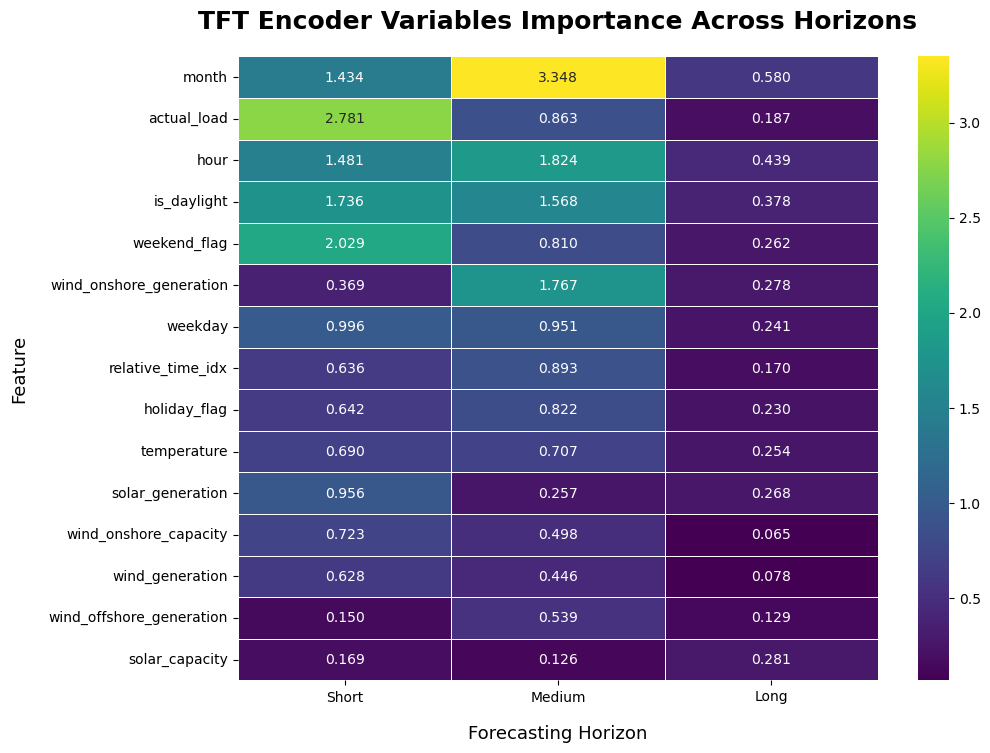

Plot saved to outputs/vsn_heatmap_encoder_variables.png



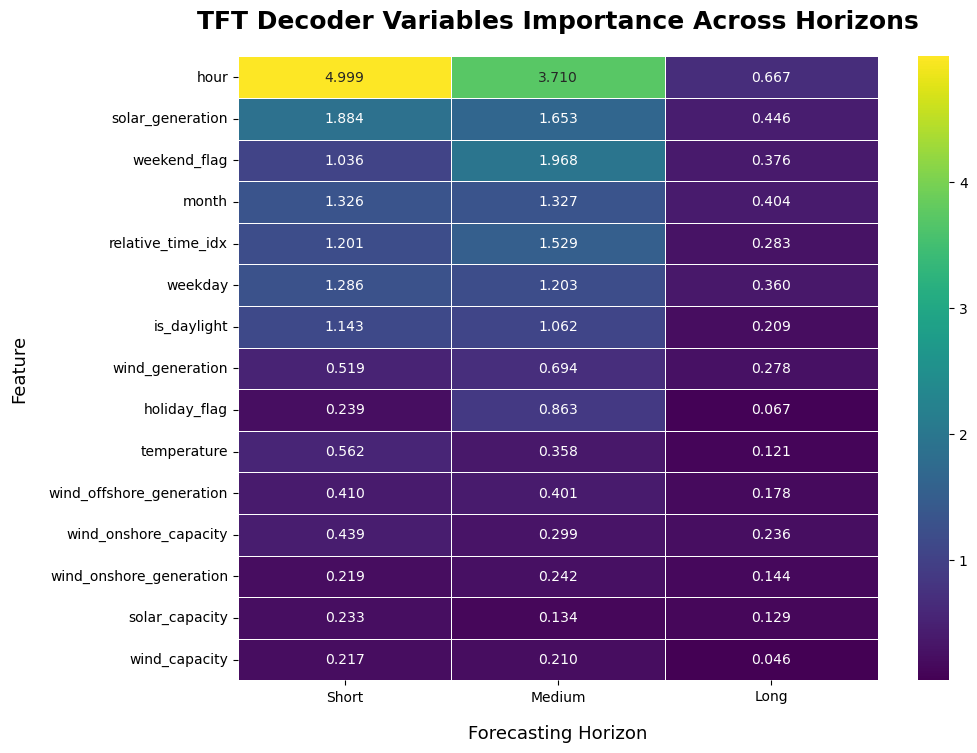

Plot saved to outputs/vsn_heatmap_decoder_variables.png



In [63]:
plot_vsn_heatmap(variable_type="encoder_variables")

plot_vsn_heatmap(variable_type="decoder_variables")

# Just playing around

In [5]:
# default styles for plots:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

file_path = '../outputs/lstm_predictions_mw_short.csv'

df_preds = pd.read_csv(file_path)
display(df_preds.head())

,actual_mw_step1,predicted_mw_step1
0,56848.92,54898.305
1,58169.77,56696.395
2,59389.38,58270.490
3,60438.76,59801.145
4,61782.72,60981.586


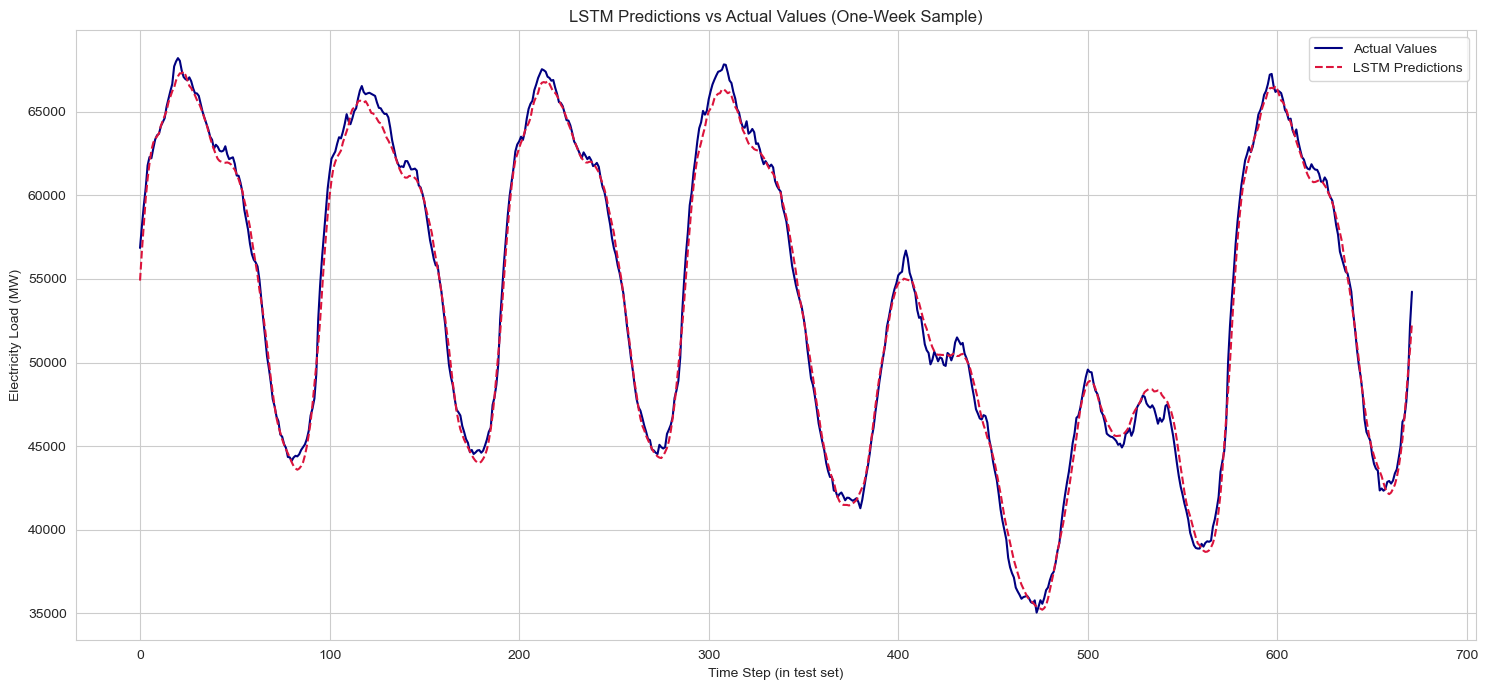

In [ ]:
start_index = 0
end_index = 672 # 7 days * 96 steps/day

plt.figure()
plt.plot(df_preds.index[start_index:end_index], df_preds['actual_mw_step1'][start_index:end_index], label='Actual Values', color='navy')
plt.plot(df_preds.index[start_index:end_index], df_preds['predicted_mw_step1'][start_index:end_index], label='LSTM Predictions', color='crimson', linestyle = '--')

plt.title('LSTM Predictions vs Actual Values (One-Week Sample)')
plt.xlabel('Time Step (in test set)')
plt.ylabel('Electricity Load (MW)')
plt.legend()
plt.tight_layout()

plt.show()

Forecast horizon vs. Visualization window:
1. Forecast Horizon - @ any single point in time, model looks at the past and predicts next 24 hours
2. Visualization Window - test contains results of model performing 'next day prediction' over and over. Therefore plotting just 1 week of this, as a representative slice. Therefore start to end index 672 accounts for 7 days.

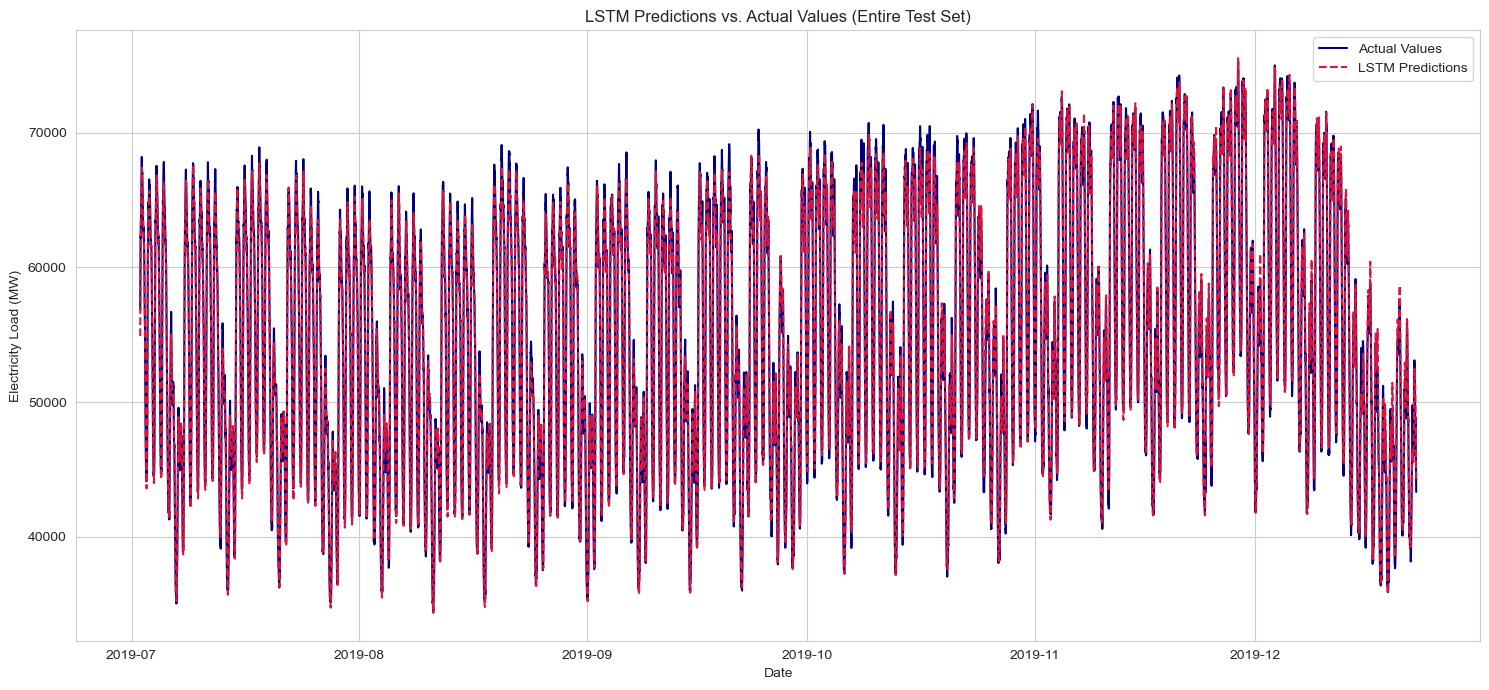

In [13]:
test_start_date = '2019-07-02 04:30:00+00:00'
datetime_index = pd.to_datetime(pd.date_range(start=test_start_date,
                                             periods = len(df_preds),
                                             freq = '15min'))
df_preds.set_index(datetime_index, inplace=True)

plt.figure()

plt.plot(df_preds.index, df_preds['actual_mw_step1'], label='Actual Values', color='navy')
plt.plot(df_preds.index, df_preds['predicted_mw_step1'], label='LSTM Predictions', color='crimson', linestyle='--')

plt.title('LSTM Predictions vs. Actual Values (Entire Test Set)')
plt.xlabel('Date') # The x-axis label is now 'Date'
plt.ylabel('Electricity Load (MW)')
plt.legend()
plt.tight_layout()

plt.show()

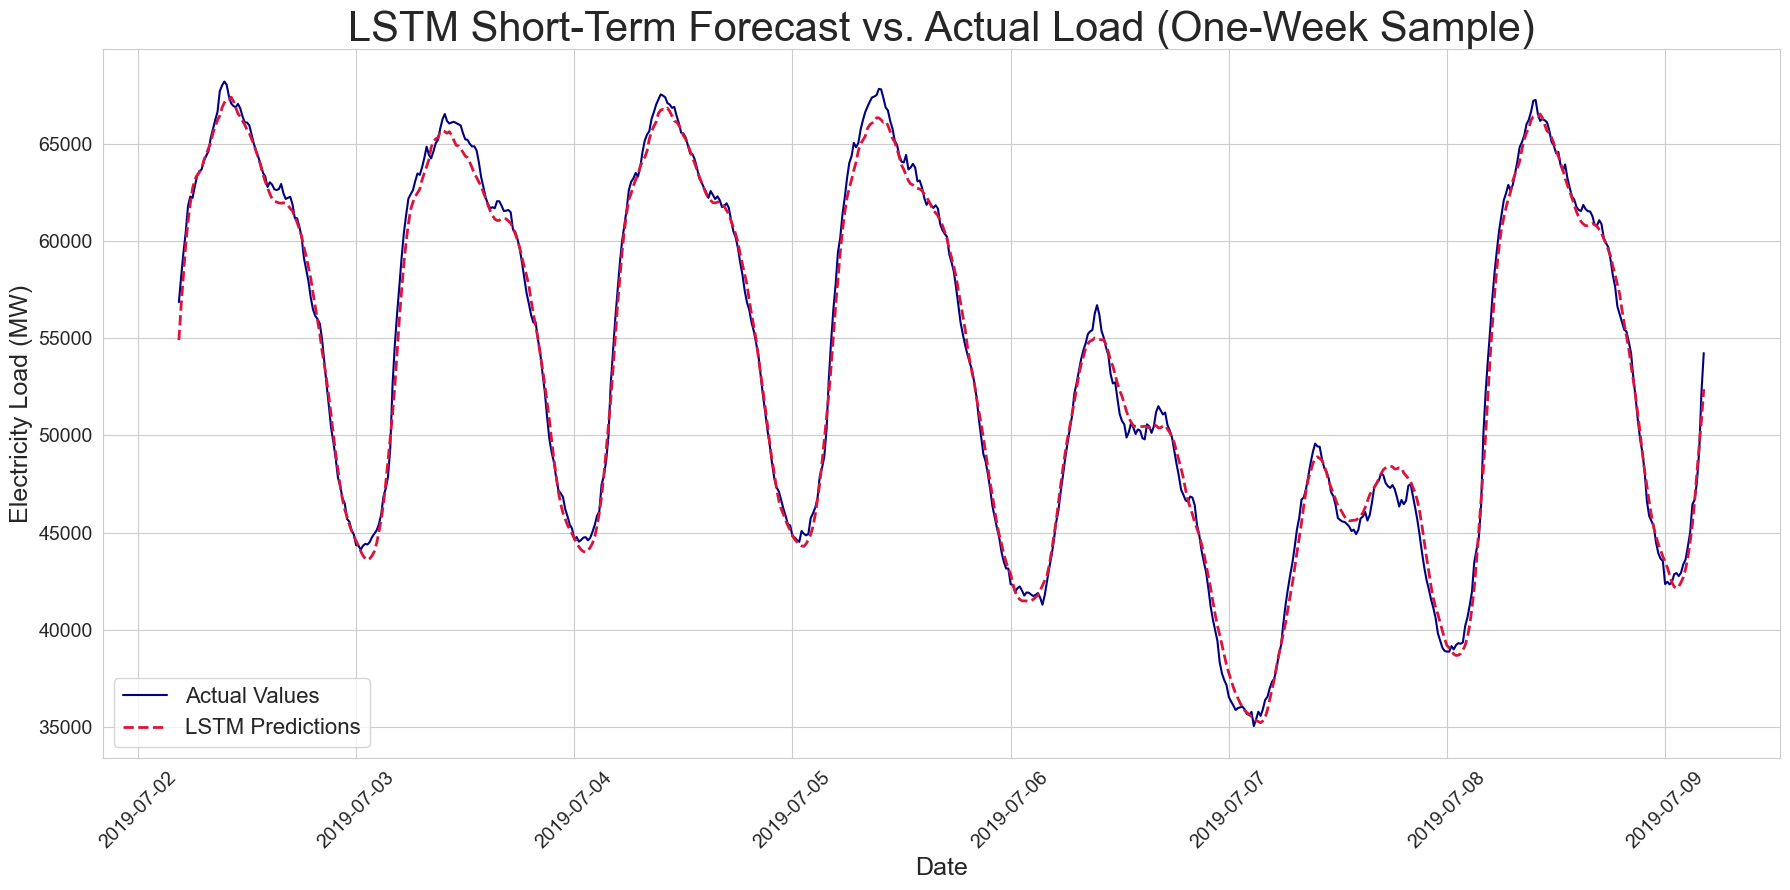

In [17]:
start_index = 0
end_index = 672

df_plot_window = df_preds.iloc[start_index:end_index]

plt.figure(figsize=(18, 9))

plt.plot(df_plot_window.index, df_plot_window['actual_mw_step1'], label='Actual Values', color='navy')
plt.plot(df_plot_window.index, df_plot_window['predicted_mw_step1'], label='LSTM Predictions', color='crimson', linestyle='--', linewidth = 2)

plt.title('LSTM Short-Term Forecast vs. Actual Load (One-Week Sample)', fontsize=30)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Electricity Load (MW)', fontsize=18)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize = 16, frameon = True, loc = 'best')
plt.tight_layout()

# plt.savefig('lstm_short_term_forecast.png', dpi=300, bbox_inches='tight')

plt.show()

In [18]:
def plot_forecast_vs_actuals(df, model_name, horizon, start_step = 0, days_to_plot = 7):
    # window to plot
    end_step = start_step + (days_to_plot * 96)  # 96 steps per day
    df_plot_window = df.iloc[start_step:end_step]

    plt.plot(df_plot_window.index, df_plot_window['actual_mw_step1'], label='Actual Values', color='navy')
    plt.plot(df_plot_window.index, df_plot_window['predicted_mw_step1'], label=f'{model_name} Predictions', color='crimson', linestyle='--', linewidth=2)

    title_text = f'{model_name} {horizon} Forecast vs. Actual Load ({days_to_plot}-Day Sample)'
    plt.title(title_text, fontsize=30)
    plt.xlabel('Date', fontsize=18)
    plt.ylabel('Electricity Load (MW)', fontsize=18)
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=16, frameon=True, loc='best')
    plt.tight_layout()

    plt.show()

# Scatter Plot for LSTM SHORT

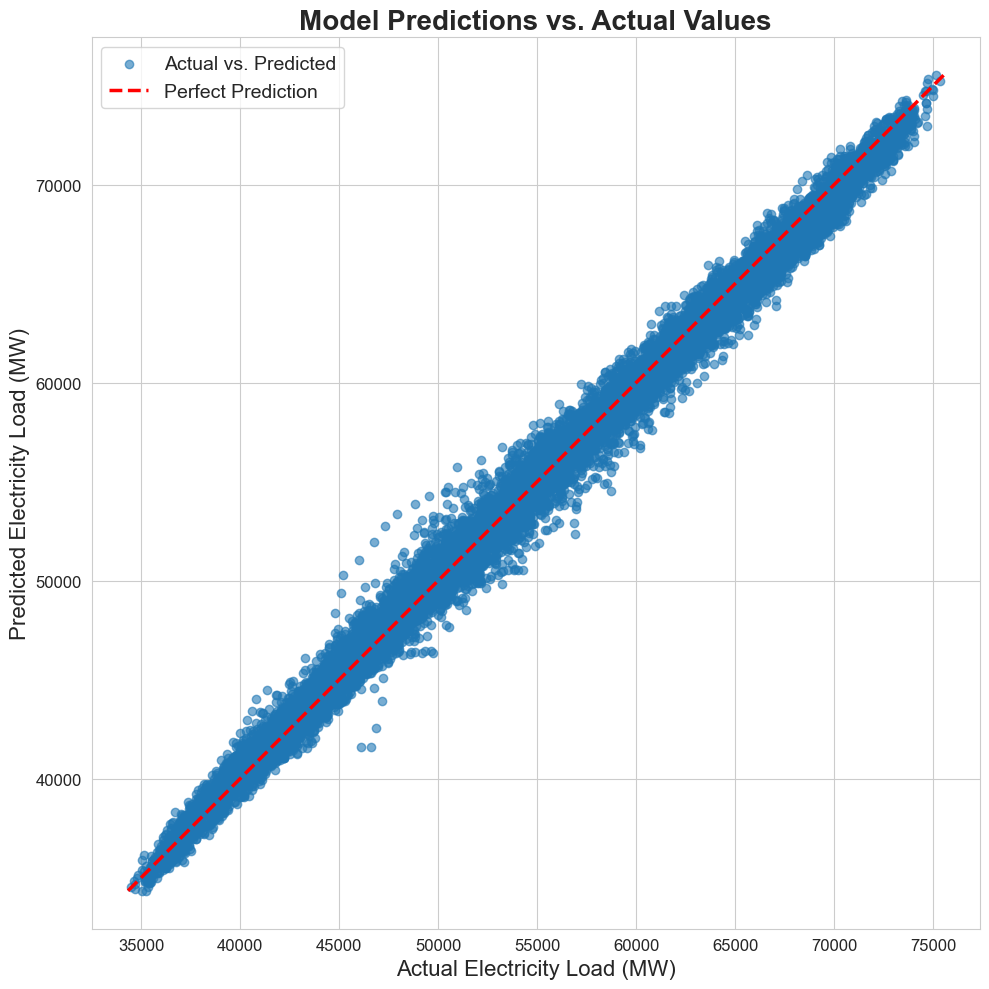

In [19]:
plt.figure(figsize=(10, 10))

plt.scatter(x = df_preds['actual_mw_step1'],
            y = df_preds['predicted_mw_step1'],
            alpha = 0.6,
            label = 'Actual vs. Predicted')

min_val = df_preds.min().min()
max_val = df_preds.max().max()
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--',
         linewidth = 2.5,
         label='Perfect Prediction')

plt.title('Model Predictions vs. Actual Values', fontsize=20, fontweight='bold')
plt.xlabel('Actual Electricity Load (MW)', fontsize=16)
plt.ylabel('Predicted Electricity Load (MW)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14, frameon=True, loc='best')

plt.axis('equal')
plt.grid(True)
plt.tight_layout()

plt.show()

First impressions:
1. High accuracy and correlation (closely aligned with perfect prediction line). Strong (+) correlation between model's predictions and actual values.
2. No obvious systemic bias. Cluster of points is centered on the red line across the entire range. Model doesn't have a siple, naive bias. Errors balanced around zero.
3. Subtle under-prediction at extremem peaks. Right top corner, above 70000MW, slight tendency for blue dots to fall just below red line. Model struggles a bit to predict the absolute highest peaks in demand.
4. Slightly Higher Error at Extremes: cloud of points gets thicker at the bottom left. Model's prediction errors are a bit larger when the load is unusually low or unusually high. Most confident during normal conditions

IS 4 really the case?

# Residuals Plot for LSTM SHORT


Summary Statistics of Residuals:
count    16683.000000
mean        47.188432
std        871.444406
min      -5466.484000
25%       -507.926000
50%         54.400000
75%        597.721500
max       5018.058000
Name: residuals, dtype: float64


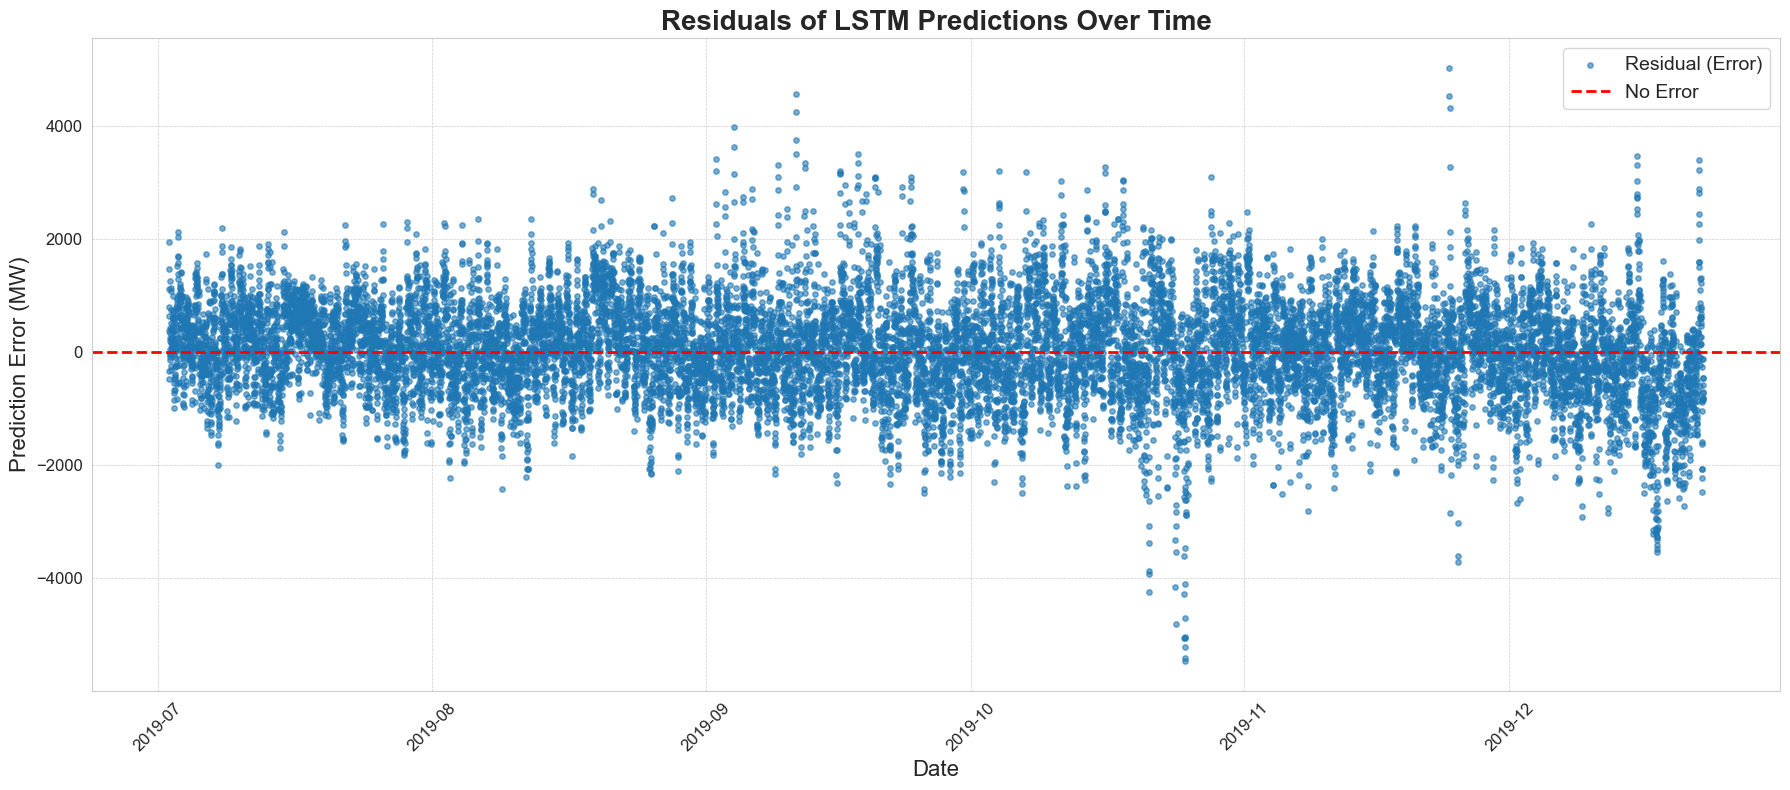

In [22]:
df_preds['residuals'] = df_preds['actual_mw_step1'] - df_preds['predicted_mw_step1']

plt.figure(figsize=(18, 8))

plt.scatter(df_preds.index, df_preds['residuals'],
            alpha = 0.6,
            s = 15,
            label = 'Residual (Error)')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No Error')

plt.title('Residuals of LSTM Predictions Over Time', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Prediction Error (MW)', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

print("\nSummary Statistics of Residuals:")
print(df_preds['residuals'].describe())

Analysis:
1. Errors are Centered on Zero: dense cloud of dots centered nicely on the red. Confirmed by mean from statistics. Model is unbiased!
2. No obvious waves/patterns. Errors are random or static. No repeating, wave like shapes. Model has successfully learned the major time-dependent patterns (daily/weekly cycles), rest is noise
3. Spread of errors != constant (heteroscedasticity). Vertical spread of the points change over time
- Periods where blue dots are tightly packed (2019-09 and end of 2019-10)
- Model's accuracy is not uniform over time. More confident during certain periods, less during others (still sensitive to volatility)